In [1]:
from data_utils import *
from import_pkgs import *

___

### Fig 1a: MUSICAv0 ne30x8_np4 scrip

___

In [11]:
MUSICA_scrip_path  = Path("/glade/work/yifanc17/02_data/cesmdata/meshdata/MUSICA/NAEUAS01_ne30x8_np4/NAEUAS01_ne30x8_np4_SCRIP.nc") 

EDGE_COLOR  = "black"
EDGE_WIDTH  = 0.22
EDGE_ALPHA  = 0.9
FIG_WIDTH   = 11.0
FIG_HEIGHT  = 4.5

FINE_AREA_FACTOR = 0.22
FINE_FACECOLOR   = "black"
FINE_ALPHA       = 0.18

In [3]:
def normalize_lon(lon):
    return ((lon + 180.0) % 360.0) - 180.0

def unwrap_polygon_lons(lons):
    out = np.asarray(lons, dtype=float).copy()
    out[0] = normalize_lon(out[0])
    for i in range(1, len(out)):
        candidates = np.array(
            [
                normalize_lon(out[i]),
                normalize_lon(out[i]) + 360.0,
                normalize_lon(out[i]) - 360.0,
            ]
        )
        out[i] = candidates[np.argmin(np.abs(candidates - out[i - 1]))]
    return out

def polygon_crosses_seam(lons):
    diffs = np.abs(np.diff(np.r_[lons, lons[0]]))
    return bool(np.any(diffs > threshold))

In [4]:
def build_edge_segments(corner_lon, corner_lat):
    segments = []
    ncell, ncorners = corner_lon.shape
    for i in range(ncell):
        lons = unwrap_polygon_lons(corner_lon[i])
        lats = corner_lat[i]
        if polygon_crosses_seam(lons, threshold=70.0):
            continue
        for j in range(ncorners):
            k = (j + 1) % ncorners
            segments.append(
                np.array([[lons[j], lats[j]], [lons[k], lats[k]]], dtype=float)
            )
    return segments

In [5]:
def build_fine_polygons(corner_lon, corner_lat, grid_area, area_factor):
    threshold = float(np.nanmedian(grid_area) * area_factor)
    select = np.isfinite(grid_area) & (grid_area <= threshold)

    polygons = []
    for i in np.where(select)[0]:
        lons = unwrap_polygon_lons(corner_lon[i])
        lats = corner_lat[i]
        if polygon_crosses_seam(lons, threshold=70.0):
            continue
        polygons.append(np.column_stack([lons, lats]))
    return polygons

In [6]:
ds = xr.open_dataset(MUSICA_scrip_path)

corner_lat = np.asarray(ds["grid_corner_lat"].values, dtype=float)
corner_lon = normalize_lon(np.asarray(ds["grid_corner_lon"].values, dtype=float))
grid_area  = np.asarray(ds["grid_area"].values, dtype=float)

print(f"Number of cells : {corner_lat.shape[0]}")
print(f"Corners per cell: {corner_lat.shape[1]}")
print(f"grid_area found : {grid_area is not None}")

Number of cells : 458111
Corners per cell: 12
grid_area found : True


In [7]:
edge_segments = build_edge_segments(corner_lon, corner_lat)
fine_polygons = build_fine_polygons(corner_lon, corner_lat, grid_area, FINE_AREA_FACTOR)

print(f"Edge segments   : {len(edge_segments)}")
print(f"Fine polygons   : {len(fine_polygons)}")

Edge segments   : 5497260
Fine polygons   : 41891


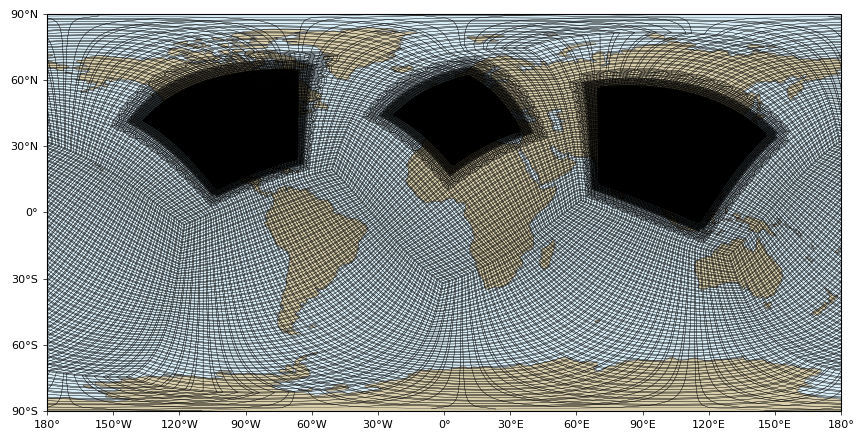

In [8]:
fig = plt.figure(figsize=(FIG_WIDTH, FIG_HEIGHT))
ax  = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([-180, 180, -90, 90], crs=ccrs.PlateCarree())

ax.add_feature(cfeature.OCEAN.with_scale("110m"), facecolor="#d9edf7", edgecolor="none", zorder=0)
ax.add_feature(cfeature.LAND.with_scale("110m"),  facecolor="#d9cfad", edgecolor="none", zorder=0)
ax.coastlines(resolution="110m", color="0.35", linewidth=0.45, zorder=2)

if fine_polygons:
    pc = PolyCollection(
        fine_polygons,
        facecolors=FINE_FACECOLOR,
        edgecolors="none",
        alpha=FINE_ALPHA,
        transform=ccrs.PlateCarree(),
        zorder=1,
    )
    ax.add_collection(pc)

lc = LineCollection(
    edge_segments,
    colors=EDGE_COLOR,
    linewidths=EDGE_WIDTH,
    alpha=EDGE_ALPHA,
    transform=ccrs.PlateCarree(),
    zorder=3,
)
ax.add_collection(lc)

xticks = np.arange(-180, 181, 30)
yticks = np.arange(-90,   91, 30)
ax.set_xticks(xticks, crs=ccrs.PlateCarree())
ax.set_yticks(yticks, crs=ccrs.PlateCarree())
ax.xaxis.set_major_formatter(cticker.LongitudeFormatter(zero_direction_label=False))
ax.yaxis.set_major_formatter(cticker.LatitudeFormatter())
ax.tick_params(labelsize=8, length=3, width=0.5)

plt.tight_layout()
plt.show()

___

### Fig 1b: model vertical layers

___

In [2]:
archive_path="/glade/derecho/scratch/yifanc17/archive/cesm2.2.2_musica_ne0np4.NAEUAS01.ne30x8_unit_test_nudged_excAsia_gt859hPa_c250623/atm/hist/"
ds = xr.open_dataset(archive_path+"cesm2.2.2_musica_ne0np4.NAEUAS01.ne30x8_unit_test_nudged_excAsia_gt859hPa_c250623.cam.h1.2024-02-01-00000.nc")

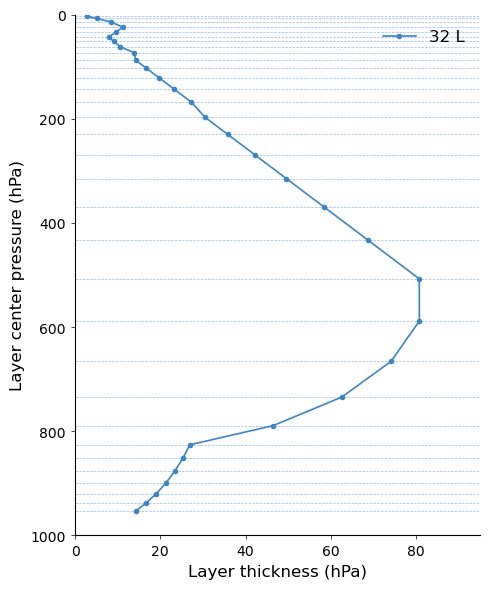

In [21]:
p_mid = ds["PMID"].isel(time=0).mean(dim="ncol").values   / 100.0  
dp    = ds["PDELDRY"].isel(time=0).mean(dim="ncol").values / 100.0

COLOR_32L = "#3d85c6"  

x_max = float(np.ceil(dp.max() / 10) * 10 + 5)

fig, ax = plt.subplots(figsize=(5,6))

for p in p_mid:
    ax.hlines(
        y=p,
        xmin=0, xmax=x_max,
        colors=COLOR_32L,
        linewidths=0.5,
        linestyles="--",
        alpha=0.55,
        zorder=1,
    )

ax.plot(
    dp, p_mid,
    linestyle="-",
    linewidth=1.2,
    marker="o",
    markersize=4,
    color=COLOR_32L,
    markerfacecolor=COLOR_32L,
    markeredgewidth=0,
    zorder=3,
    label="32 L",
)

ax.set_xlim(0, x_max)
ax.set_ylim(1000, 0)         
ax.set_xlabel("Layer thickness (hPa)", fontsize=12)
ax.set_ylabel("Layer center pressure (hPa)", fontsize=12)
ax.tick_params(labelsize=10, length=3, width=0.5)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(fontsize=12, loc="upper right", frameon=False)
plt.tight_layout()
plt.show()

___

### Fig 1c: DC8 flight track

___

In [ ]:
lat_fl=dc8_track_infile['lat_fl']
lon_fl=dc8_track_infile['lon_fl']

In [ ]:
LON_MIN, LON_MAX =  95.0, 135.0
LAT_MIN, LAT_MAX =   0.0,  42.0
TITLE       = "ne30x8 — East Asia"
EDGE_COLOR  = "black"
EDGE_WIDTH  = 0.4       
EDGE_ALPHA  = 0.9
FIG_WIDTH   = 8.0
FIG_HEIGHT  = 7.0
TICK_STEP_LON = 10      
TICK_STEP_LAT = 10
FINE_AREA_FACTOR = 0.22
FINE_FACECOLOR   = "black"
FINE_ALPHA       = 0.18
FT_CMAP  = "viridis"    
FT_VMIN  = 0
FT_VMAX  = 100
FT_SIZE  = 5
FT_COLOR = "red"

In [8]:
ds = xr.open_dataset(MUSICA_scrip_path)

corner_lat = np.asarray(ds["grid_corner_lat"].values, dtype=float)
corner_lon = normalize_lon(np.asarray(ds["grid_corner_lon"].values, dtype=float))
grid_area  = (
    np.asarray(ds["grid_area"].values, dtype=float)
    if "grid_area" in ds.variables
    else None
)

print(f"Number of cells : {corner_lat.shape[0]}")
print(f"Corners per cell: {corner_lat.shape[1]}")
print(f"grid_area found : {grid_area is not None}")

Number of cells : 458111
Corners per cell: 12
grid_area found : True


In [9]:
lon_bounds = (LON_MIN, LON_MAX)
lat_bounds = (LAT_MIN, LAT_MAX)

edge_segments = build_edge_segments(
    corner_lon, corner_lat,
    lon_bounds=lon_bounds,
    lat_bounds=lat_bounds,
)
fine_polygons = build_fine_polygons(
    corner_lon, corner_lat, grid_area, FINE_AREA_FACTOR,
    lon_bounds=lon_bounds,
    lat_bounds=lat_bounds,
)

print(f"Edge segments : {len(edge_segments)}")
print(f"Fine polygons : {len(fine_polygons)}")

Edge segments : 1260924
Fine polygons : 11266


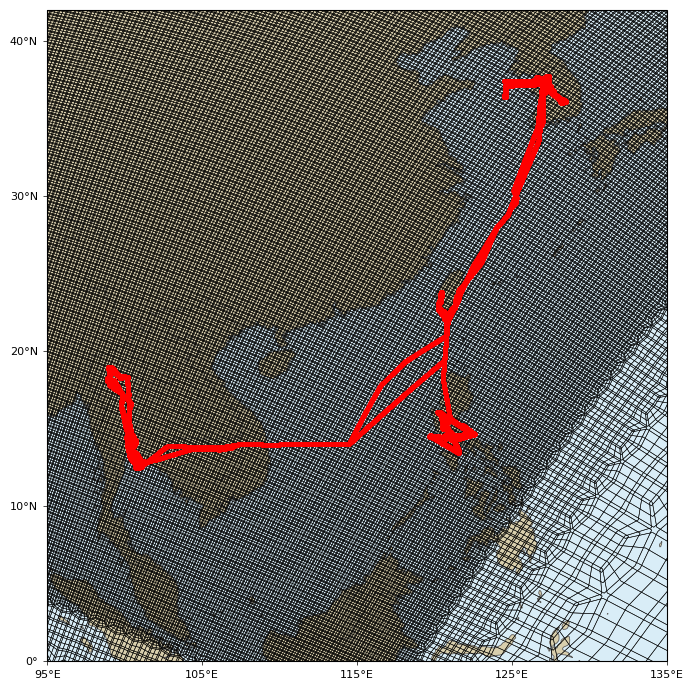

In [18]:
fig = plt.figure(figsize=(FIG_WIDTH, FIG_HEIGHT))
ax  = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([LON_MIN, LON_MAX, LAT_MIN, LAT_MAX], crs=ccrs.PlateCarree())

ax.add_feature(cfeature.OCEAN.with_scale("50m"), facecolor="#d9edf7", edgecolor="none", zorder=0)
ax.add_feature(cfeature.LAND.with_scale("50m"),  facecolor="#d9cfad", edgecolor="none", zorder=0)
ax.add_feature(cfeature.BORDERS.with_scale("50m"), linewidth=0.4, edgecolor="0.4", zorder=2)
ax.coastlines(resolution="50m", color="0.35", linewidth=0.6, zorder=2)

if fine_polygons:
    pc = PolyCollection(
        fine_polygons,
        facecolors=FINE_FACECOLOR,
        edgecolors="none",
        alpha=FINE_ALPHA,
        transform=ccrs.PlateCarree(),
        zorder=1,
    )
    ax.add_collection(pc)

lc = LineCollection(
    edge_segments,
    colors=EDGE_COLOR,
    linewidths=EDGE_WIDTH,
    alpha=EDGE_ALPHA,
    transform=ccrs.PlateCarree(),
    zorder=3,
)
ax.add_collection(lc)

if lon_fl.size > 0 and lat_fl.size > 0:
    use_colormap = (color_fl is not None) and (len(color_fl) == len(lon_fl))
    flight = ax.scatter(
        lon_fl, lat_fl,
        c=color_fl if use_colormap else FT_COLOR,
        cmap=FT_CMAP if use_colormap else None,
        s=FT_SIZE,
        vmin=FT_VMIN if use_colormap else None,
        vmax=FT_VMAX if use_colormap else None,
        transform=ccrs.PlateCarree(),
        zorder=5,
        label="Flight track",
    )
    if use_colormap:
        plt.colorbar(flight, ax=ax, orientation="vertical",
                     pad=0.02, shrink=0.7, label="Flight variable")

xticks = np.arange(LON_MIN, LON_MAX + 1, TICK_STEP_LON)
yticks = np.arange(LAT_MIN, LAT_MAX + 1, TICK_STEP_LAT)
ax.set_xticks(xticks, crs=ccrs.PlateCarree())
ax.set_yticks(yticks, crs=ccrs.PlateCarree())
ax.xaxis.set_major_formatter(cticker.LongitudeFormatter(zero_direction_label=False))
ax.yaxis.set_major_formatter(cticker.LatitudeFormatter())
ax.tick_params(labelsize=8, length=3, width=0.5)

plt.tight_layout()
plt.show()

___

### Figs 1d-1g: locations of ground observation sites

___

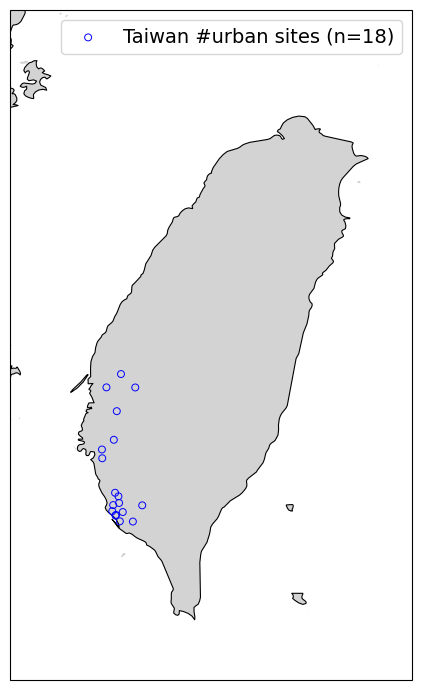

In [3]:
tw_lats, tw_lons = [], []

for site_id in URBAN_IDS_TW:
    site_name = tw_site_map[site_id]
    site_lat, site_lon = tw_site_info.loc[
        tw_site_info["siteengname"] == site_name, ["lat", "lon"]
    ].values[0]
    tw_lats.append(site_lat)
    tw_lons.append(site_lon)

tw_lats = np.array(tw_lats)
tw_lons = np.array(tw_lons)

fig = plt.figure(figsize=(6, 7))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([119.6, 122.3, 21.5, 26], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, facecolor="lightgray")
ax.add_feature(cfeature.OCEAN, facecolor="white")
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.6)

ax.scatter(
    tw_lons,
    tw_lats,
    s=25,
    facecolors="none",
    edgecolors="blue",
    linewidths=0.7,
    marker="o",
    transform=ccrs.PlateCarree(),
    zorder=5,
    label=f"Taiwan #urban sites (n={len(URBAN_IDS_TW)})",
)

ax.legend(fontsize=14)
plt.tight_layout()

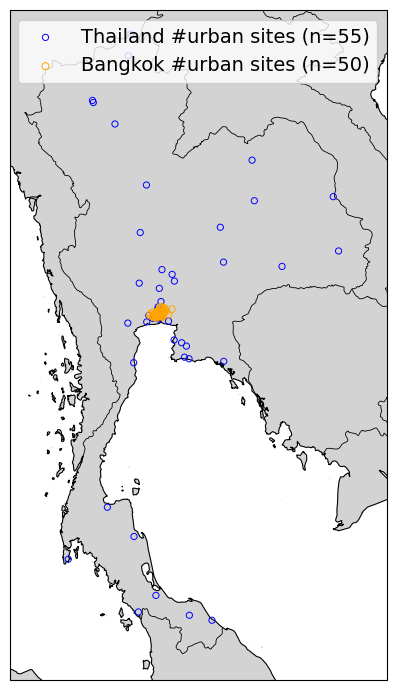

In [7]:
pcd_lats=[]
pcd_lons=[]
bma_lats=[]
bma_lons=[]
pcd_aq_info = pd.read_csv(TH_CONC + "PCD_stations/Thailand_PCD_station_info_conc.csv")
bma_aq_info = pd.read_csv(TH_CONC + "BMA_stations/Thailand_BMA_station_info_conc.csv")
for i, site_id in enumerate(TH_AQ_URBAN_IDS):
    site_lat, site_lon = pcd_aq_info.loc[
        pcd_aq_info["stationID"]==site_id, ["latitude_north","longitude_east"]
    ].values[0]
    pcd_lats.append(site_lat)
    pcd_lons.append(site_lon)
for i, site_id in enumerate(BMA_AQ_URBAN_IDS):
    site_lat, site_lon = bma_aq_info.loc[
        bma_aq_info["stationID"]==site_id, ["latitude_north","longitude_east"]
    ].values[0]
    bma_lats.append(site_lat)
    bma_lons.append(site_lon)

fig = plt.figure(figsize=(6, 7))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.set_extent([97,106,5,21], crs=ccrs.PlateCarree())

ax.add_feature(cfeature.LAND, facecolor="lightgray")
ax.add_feature(cfeature.OCEAN, facecolor="white")
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.6)

ax.scatter(
    pcd_lons,
    pcd_lats,
    s=20,
    facecolors="none",     
    edgecolors="blue",      
    linewidths=0.7,
    marker="o",
    transform=ccrs.PlateCarree(),
    zorder=5,
    label=f"Thailand #urban sites (n={len(TH_AQ_URBAN_IDS)})"
)

ax.scatter(
    bma_lons,
    bma_lats,
    s=25,
    facecolors="none",      # transparent fill
    edgecolors="orange",       # red outline
    linewidths=0.7,
    marker="o",
    transform=ccrs.PlateCarree(),
    zorder=5,
    label=f"Bangkok #urban sites (n={len(BMA_AQ_URBAN_IDS)})"
)

ax.legend(fontsize=14)
plt.tight_layout()

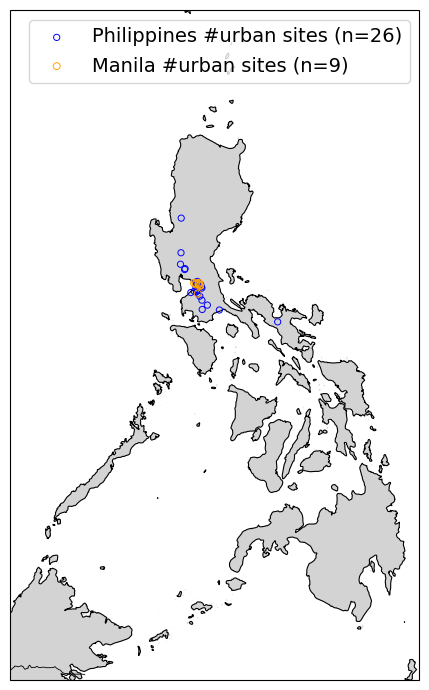

In [5]:
lufft_lats=[]
lufft_lons=[]
davis_lats=[]
davis_lons=[]

for i, site_id in enumerate(manila_lufft_ids):
    site_lat, site_lon = manila_lufft_stations.loc[
        manila_lufft_stations["Site ID"]==site_id, ["Lat","Lon"]
    ].values[0]
    lufft_lats.append(site_lat)
    lufft_lons.append(site_lon)
for i, site_id in enumerate(manila_davis_ids):
    site_lat, site_lon = manila_davis_stations.loc[
        manila_davis_stations["Site ID"]==site_id, ["Latitude","Longitude"]
    ].values[0]
    davis_lats.append(site_lat)
    davis_lons.append(site_lon)
fig = plt.figure(figsize=(6, 7))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.set_extent([116,127,4,22], crs=ccrs.PlateCarree())

ax.add_feature(cfeature.LAND, facecolor="lightgray")
ax.add_feature(cfeature.OCEAN, facecolor="white")
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.6)

ax.scatter(
    lufft_lons,
    lufft_lats,
    s=20,
    facecolors="none",      
    edgecolors="blue",       
    linewidths=0.7,
    marker="o",
    transform=ccrs.PlateCarree(),
    zorder=5,
    label=f"Philippines #urban sites (n={len(manila_lufft_ids)})"
)

ax.scatter(
    davis_lons,
    davis_lats,
    s=25,
    facecolors="none",     
    edgecolors="orange",      
    linewidths=0.7,
    marker="o",
    transform=ccrs.PlateCarree(),
    zorder=5,
    label=f"Manila #urban sites (n={len(manila_davis_ids)})"
)

ax.legend(fontsize=14)
plt.tight_layout()

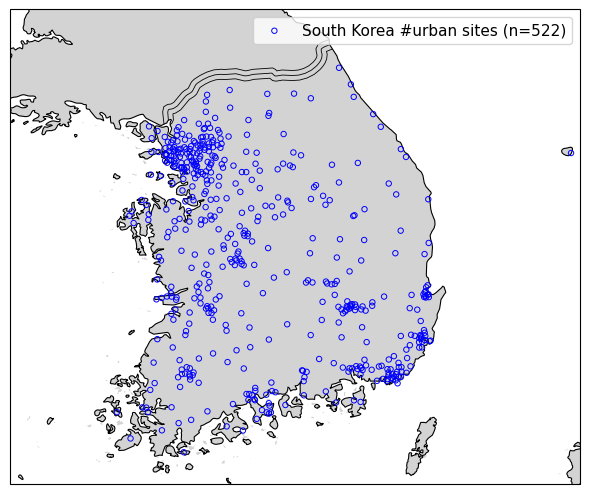

In [6]:
# loc station
lats=[]
lons=[]

for i, site_id in enumerate(SK_urban_site_ids):
    site_lat, site_lon = korea_site_info.loc[
        korea_site_info["SiteCode"]==site_id, ["Lat","Lon"]
    ].values[0]
    lats.append(site_lat)
    lons.append(site_lon)

fig = plt.figure(figsize=(6, 7))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.set_extent([125, 131, 34, 39], crs=ccrs.PlateCarree())

ax.add_feature(cfeature.LAND, facecolor="lightgray")
ax.add_feature(cfeature.OCEAN, facecolor="white")
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.6)

ax.scatter(
    lons,
    lats,
    s=15,
    facecolors="none",      
    edgecolors="blue",       
    linewidths=0.7,
    marker="o",
    transform=ccrs.PlateCarree(),
    zorder=5,
    label=f"South Korea #urban sites (n={len(SK_urban_site_ids)})"
)

ax.legend(fontsize=11)
plt.tight_layout()

___

### Fig 1h: GCAS NO2 flight track

___

/glade/derecho/scratch/yifanc17/tmp/ipykernel_55354/1058051872.py:28: RuntimeWarning: Mean of empty slice
  track_lon = np.nanmean(lon_masked, axis=1)
/glade/derecho/scratch/yifanc17/tmp/ipykernel_55354/1058051872.py:29: RuntimeWarning: Mean of empty slice
  track_lat = np.nanmean(lat_masked, axis=1)
/glade/derecho/scratch/yifanc17/tmp/ipykernel_55354/1058051872.py:28: RuntimeWarning: Mean of empty slice
  track_lon = np.nanmean(lon_masked, axis=1)
/glade/derecho/scratch/yifanc17/tmp/ipykernel_55354/1058051872.py:29: RuntimeWarning: Mean of empty slice
  track_lat = np.nanmean(lat_masked, axis=1)
/glade/derecho/scratch/yifanc17/tmp/ipykernel_55354/1058051872.py:28: RuntimeWarning: Mean of empty slice
  track_lon = np.nanmean(lon_masked, axis=1)
/glade/derecho/scratch/yifanc17/tmp/ipykernel_55354/1058051872.py:29: RuntimeWarning: Mean of empty slice
  track_lat = np.nanmean(lat_masked, axis=1)
/glade/derecho/scratch/yifanc17/tmp/ipykernel_55354/1058051872.py:28: RuntimeWarning: Mean of 

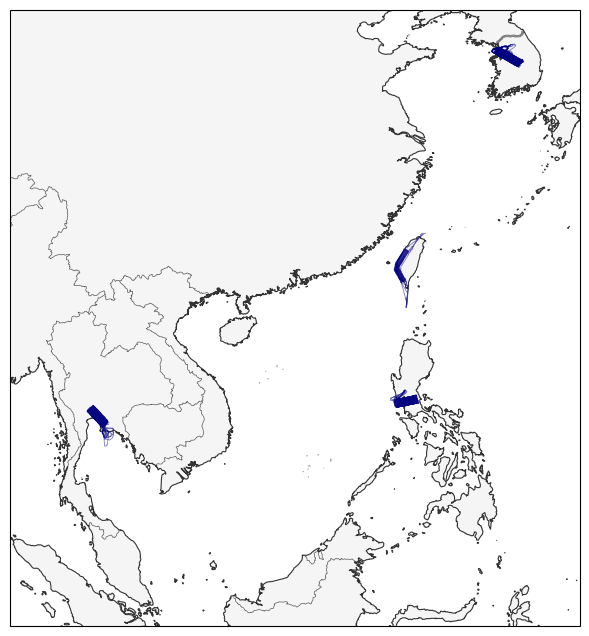

In [29]:
fig, ax = plt.subplots(
    1, 1, figsize=(10, 8),
    subplot_kw={"projection": ccrs.PlateCarree()}
)

ax.set_extent([95, 132, 0, 40], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND.with_scale("10m"), facecolor="#f5f5f5")
ax.add_feature(cfeature.OCEAN.with_scale("10m"), facecolor="white")
ax.add_feature(cfeature.BORDERS.with_scale("10m"), edgecolor="0.35", linewidth=0.5)
ax.coastlines(resolution="10m", color="0.2", linewidth=0.8)

for path in Path(gcas_path).glob("asiaaq-GCAS-NO2_LaRC-G3_2024*_R1.nc"):
    ds = xr.open_dataset(path)

    lon = normalize_lon(ds["lon"].values)
    lat = ds["lat"].values
    cloud = ds["cloud_glint_flag"].values
    obs = ds["no2_vertical_column_below_aircraft"].values

    valid = np.isfinite(lon) & np.isfinite(lat) & np.isfinite(obs) & (cloud == 0)

    lon_masked = np.where(valid, lon, np.nan)
    lat_masked = np.where(valid, lat, np.nan)

    track_lon = np.nanmean(lon_masked, axis=1)
    track_lat = np.nanmean(lat_masked, axis=1)

    ok = np.isfinite(track_lon) & np.isfinite(track_lat)

    ax.plot(
        track_lon[ok],
        track_lat[ok],
        color="navy",
        lw=0.6,
        alpha=0.5,
        transform=ccrs.PlateCarree()
    )

    ds.close()

ax.set_title("")